In [1]:
import numpy as np
import pandas as pd
import math
from tkinter import messagebox
from PIL import Image, ImageDraw
from datetime import datetime
import matplotlib.pyplot as plt
import random


np.set_printoptions(threshold=np.inf)

In [2]:
data_train = pd.read_csv("/home/pavel/work/notebook/Mnist3/mnist_train.csv", header  = None)
data_test = pd.read_csv("/home/pavel/work/notebook/Mnist3/mnist_test.csv", header  = None)

In [3]:
data_train = np.array(data_train)
data_test = np.array(data_test)
data_train = data_train.T
data_test = data_test.T

In [4]:
n1, v1 = data_train.shape
Y_train = data_train[0]
X_train = data_train[1:n1]
n2, v2 = data_test.shape
Y_test = data_test[0]
X_test = data_test[1:n2]
X_train = X_train / 255.0
X_test = X_test / 255.0
print(Y_train.shape, X_train.shape)

(60000,) (784, 60000)


In [5]:
def One_hot(Test, clases_count):
    one_hot = np.zeros((clases_count, Test.shape[0]))
    for i in range(Test.shape[0]):
        one_hot[Test[i], i] = 1
    return one_hot
    

In [6]:
def init_weights():
    # Xavier/Glorot инициализация
    w1 = np.random.randn(128, 784) * np.sqrt(2. / 784) 
    bias1 = np.zeros((128, 1))
    
    w2 = np.random.randn(64, 128) * np.sqrt(2. / 128)
    bias2 = np.zeros((64, 1))
    
    w3 = np.random.randn(10, 64) * np.sqrt(2. / 64)  
    bias3 = np.zeros((10, 1))
    
    return w1, bias1, w2, bias2, w3, bias3

In [7]:
def Relu(x):
    return np.maximum(0, x)

In [8]:
def SoftMax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

In [9]:
def forward_prop(w1, bias1, w2, bias2, w3, bias3, X):
    Z1 = w1.dot(X) + bias1
    A1 = Relu(Z1)

    Z2 = w2.dot(A1) + bias2
    A2 = Relu(Z2)

    Z3 = w3.dot(A2) + bias3
    A3 = SoftMax(Z3)
    
    return Z1, A1, Z2, A2, Z3, A3

In [10]:
def Cross_Entropy_Loss(Y_true, Y_pred):
    return -np.sum(Y_true * np.log(Y_pred + 1e-8)) / Y_true.shape[1]


In [11]:
def Back_prop(X, Y, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    m = Y.shape[1]

    dZ3 = A3 - Y
    dW3 = dZ3.dot(A2.T) / m
    db3 = np.sum(dZ3, axis = 1, keepdims = True) / m
    
    dA2 = W3.T.dot(dZ3)
    dZ2 = dA2 * (Z2 > 0)
    dW2 = dZ2.dot(A1.T) / m
    db2 = np.sum(dZ2, axis = 1, keepdims = True) / m
    
    dA1 = W2.T.dot(dZ2)
    dZ1 = dA1 * (Z1 > 0)
    dW1 = dZ1.dot(X.T) / m
    db1 = np.sum(dZ1, axis = 1, keepdims = True) / m
    
    return dW1, db1, dW2, db2, dW3, db3
    
    

In [12]:
def update_parameters(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate):
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    W1 = np.clip(W1, -1.0, 1.0)
    W2 = np.clip(W2, -1.0, 1.0)
    W3 = np.clip(W3, -1.0, 1.0)

    return W1, b1, W2, b2, W3, b3
    

In [13]:
def Predict(W1, b1, W2, b2, W3, b3, x):
    _, _, _, _, _, A3 = forward_prop(W1, b1, W2, b2, W3, b3, x)
    return np.argmax(A3, axis = 0)

In [14]:
from IPython.display import clear_output

def train_with_animation(X_train, Y_train, X_test, Y_test, learning_rate=0.001, epochs=80, batch_size=64):
    W1, b1, W2, b2, W3, b3 = init_weights()
    Y_train_hot = One_hot(Y_train, 10)
    m = X_train.shape[1]
    
    history = {'loss': [], 'accuracy': []}
    
    plt.figure(figsize=(12, 4))
    
    for epoch in range(epochs):
        perm = np.random.permutation(m)
        X_shuffled = X_train[:, perm]
        Y_shuffled = Y_train_hot[:, perm]
        
        epoch_loss = 0
        num_batches = 0
        
        for i in range(0, m, batch_size):
            batch_end = min(i + batch_size, m)
            X_batch = X_shuffled[:, i:batch_end]
            Y_batch = Y_shuffled[:, i:batch_end]
            
            Z1, A1, Z2, A2, Z3, A3 = forward_prop(W1, b1, W2, b2, W3, b3, X_batch)
            loss = Cross_Entropy_Loss(Y_batch, A3)
            epoch_loss += loss
            num_batches += 1
            
            dW1, db1, dW2, db2, dW3, db3 = Back_prop(X_batch, Y_batch, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3)
            W1, b1, W2, b2, W3, b3 = update_parameters(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate)
        
        avg_loss = epoch_loss / num_batches
        history['loss'].append(avg_loss)
        
        # Тестовая точность
        _, _, _, _, _, A3_test = forward_prop(W1, b1, W2, b2, W3, b3, X_test)
        predictions = np.argmax(A3_test, axis=0)
        accuracy = np.mean(predictions == Y_test)
        history['accuracy'].append(accuracy)
        
        # Очистка и перерисовка
        clear_output(wait=True)
        
        plt.clf()
        
        # График loss
        plt.subplot(1, 3, 1)
        plt.plot(history['loss'], 'b-', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss')
        plt.grid(True, alpha=0.3)
        
        # График accuracy
        plt.subplot(1, 3, 2)
        plt.plot(history['accuracy'], 'g-', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Test Accuracy')
        plt.ylim([0, 1])
        plt.grid(True, alpha=0.3)
        
        # Пример предсказания
        plt.subplot(1, 3, 3)
        test_idx = np.random.randint(0, X_test.shape[1])
        x_sample = X_test[:, test_idx:test_idx+1]
        pred = Predict(W1, b1, W2, b2, W3, b3, x_sample)
        plt.imshow(X_test[:, test_idx].reshape(28, 28), cmap='gray')
        plt.title(f'Pred: {pred[0]} | True: {Y_test[test_idx]}', fontsize=12)
        plt.axis('off')
        
        plt.suptitle(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {accuracy:.4f}', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.6f} | Accuracy: {accuracy:.4f}")
    
    return W1, b1, W2, b2, W3, b3, history






In [94]:
#W1, b1, W2, b2, W3, b3  = init_weights()

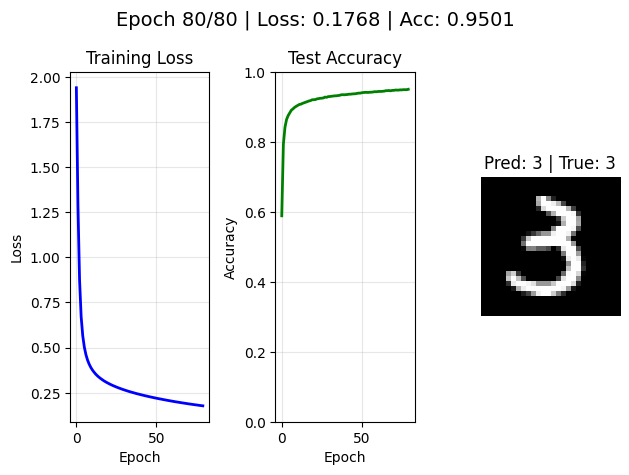

Epoch  79 | Loss: 0.176782 | Accuracy: 0.9501


In [15]:
W1, b1, W2, b2, W3, b3, history = train_with_animation(X_train, Y_train, X_test, Y_test, learning_rate=0.001, epochs=80, batch_size=64)

Ошибок: 522 | Точность: 94.78%


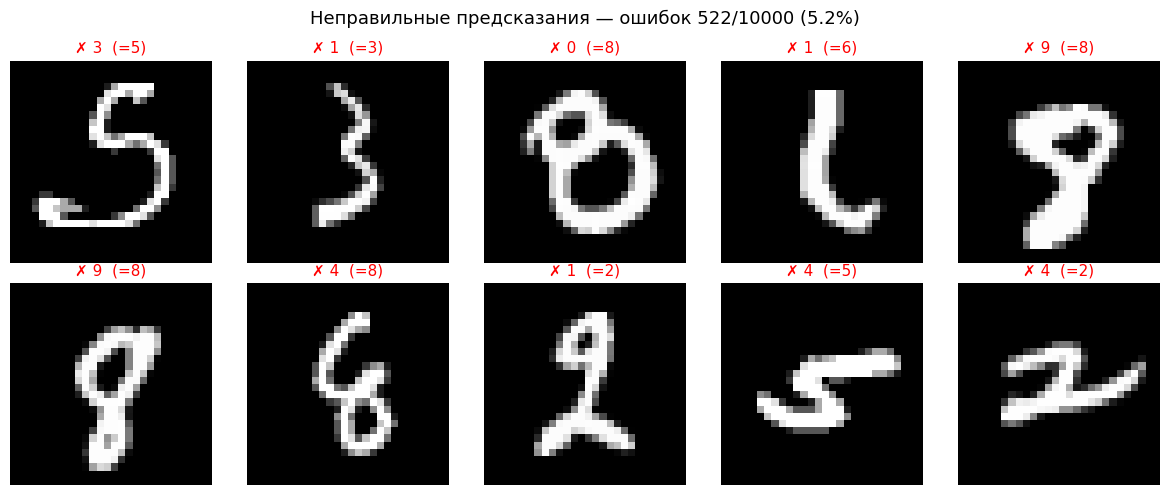

In [112]:
err = 0
wrong_samples = []

for i in range(10000):
    pred = Predict(W1, b1, W2, b2, W3, b3, X_test[:, i:i+1])[0]
    true = Y_test[i]
    if pred != true:
        err += 1
        wrong_samples.append((X_test[:, i], pred, true))

print(f"Ошибок: {err} | Точность: {(1 - err/10000)*100:.2f}%")

sample = random.sample(wrong_samples, 10)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle(f"Неправильные предсказания — ошибок {err}/10000 ({err/100:.1f}%)", fontsize=13)

for i, ax in enumerate(axes.flat):
    img, pred, true = sample[i]
    ax.imshow(img.reshape(28, 28), cmap="gray")
    ax.set_title(f"✗ {pred}  (={true})", color="red", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [109]:
with open ("/home/pavel/work/notebook/Mnist3/parameters/W1.txt", 'w') as f:
    f.write(str(W1))
with open ("/home/pavel/work/notebook/Mnist3/parameters/W2.txt", 'w') as f:
    f.write(str(W2))
with open ("/home/pavel/work/notebook/Mnist3/parameters/W3.txt", 'w') as f:
    f.write(str(W3))
with open ("/home/pavel/work/notebook/Mnist3/parameters/b1.txt", 'w') as f:
    f.write(str(b1))
with open ("/home/pavel/work/notebook/Mnist3/parameters/b2.txt", 'w') as f:
    f.write(str(b2))
with open ("/home/pavel/work/notebook/Mnist3/parameters/b3.txt", 'w') as f:
    f.write(str(b3))